# 3. Mushroom Foraging


In this assignment, I was given a mushroom dataset with features such as cap shape, cap color, stem size, habitat, and the target class. 
The task was to build a machine learning model that predicts whether a mushroom is edible or poisonous. This is supervised learning because the correct answer, edible or poisonous, is already given in the dataset. It is also a classification problem because the output is a category, not a continuous number.

## Imports


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score,
    precision_recall_curve,
    classification_report
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 100)


## Load Data


In [36]:
data = pd.read_csv("secondary_data.csv", delimiter=";")
print(data.shape)
data.head()


(61069, 21)


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w


In [37]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type             3177 non-null   object 
 15  veil-color         

In [38]:
data.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
class,61069,2,p,33888,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cap-diameter,61069.0,NaN,NaN,NaN,6.733854,5.264845,0.38,3.48,5.86,8.54,62.34
cap-shape,61069,7,x,26934,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cap-surface,46949,11,t,8196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cap-color,61069,12,n,24218,NaN,NaN,NaN,NaN,NaN,NaN,NaN
does-bruise-or-bleed,61069,2,f,50479,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gill-attachment,51185,7,a,12698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gill-spacing,36006,3,c,24710,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gill-color,61069,12,w,18521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stem-height,61069.0,NaN,NaN,NaN,6.581538,3.370017,0.0,4.64,5.95,7.74,33.92


## Initial Overview


In [ ]:
data.dtypes

class                    object
cap-diameter            float64
cap-shape                object
cap-surface              object
cap-color                object
does-bruise-or-bleed     object
gill-attachment          object
gill-spacing             object
gill-color               object
stem-height             float64
stem-width              float64
stem-root                object
stem-surface             object
stem-color               object
veil-type                object
veil-color               object
has-ring                 object
ring-type                object
spore-print-color        object
habitat                  object
season                   object
dtype: object

In [40]:
data.isna().sum().sort_values(ascending=False)


veil-type               57892
spore-print-color       54715
veil-color              53656
stem-root               51538
stem-surface            38124
gill-spacing            25063
cap-surface             14120
gill-attachment          9884
ring-type                2471
class                       0
stem-color                  0
habitat                     0
has-ring                    0
stem-width                  0
cap-diameter                0
stem-height                 0
gill-color                  0
does-bruise-or-bleed        0
cap-color                   0
cap-shape                   0
season                      0
dtype: int64

In [43]:
print(data["class"].value_counts())
print(data["class"].value_counts(normalize=True))


class
p    33888
e    27181
Name: count, dtype: int64
class
p    0.554913
e    0.445087
Name: proportion, dtype: float64


## Data Cleaning And Preparation


In [45]:
# Check duplicates without changing the dataset yet
duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


Number of duplicate rows: 146


# Prepare X & y

In [47]:
# Prepare X and y before preprocessing
X = data.drop(columns=["class"]) # Features
y = data["class"] # Target variable

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (61069, 20)
y shape: (61069,)


In [48]:
# Split before fitting imputers, encoders, scalers or selecting columns
X_train_val, X_test, y_train_val, y_test = train_test_split( # Initial Training Split
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split( # Validation Split
    X_train_val, y_train_val, 
    test_size=0.25, 
    random_state=42, 
    stratify=y_train_val
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)


X_train: (36641, 20)
X_val: (12214, 20)
X_test: (12214, 20)


In [49]:
print("Train target distribution:")
print(y_train.value_counts(normalize=True))
print()
print("Validation target distribution:")
print(y_val.value_counts(normalize=True))
print()
print("Test target distribution:")
print(y_test.value_counts(normalize=True))


Train target distribution:
class
p    0.554898
e    0.445102
Name: proportion, dtype: float64

Validation target distribution:
class
p    0.554937
e    0.445063
Name: proportion, dtype: float64

Test target distribution:
class
p    0.554937
e    0.445063
Name: proportion, dtype: float64


In [55]:
# Decide which columns to drop using only the training data
missing_ratio_train = X_train.isna().mean().sort_values(ascending=False).round(4)
missing_ratio_train


stem-surface            0.6245
gill-spacing            0.4116
cap-surface             0.2297
gill-attachment         0.1598
ring-type               0.0395
cap-diameter            0.0000
cap-shape               0.0000
cap-color               0.0000
does-bruise-or-bleed    0.0000
gill-color              0.0000
stem-height             0.0000
stem-width              0.0000
stem-color              0.0000
has-ring                0.0000
habitat                 0.0000
season                  0.0000
dtype: float64

In [56]:
cols_to_drop = missing_ratio_train[missing_ratio_train > 0.80].index.tolist()
print(f"Columns to drop (more than 80% missing in training data): {cols_to_drop}")

Columns to drop (more than 80% missing in training data): []


In [57]:
X_train = X_train.drop(columns=cols_to_drop)
X_val = X_val.drop(columns=cols_to_drop)
X_train_val = X_train_val.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

print("X_train after dropping columns:", X_train.shape)
print("X_val after dropping columns:", X_val.shape)
print("X_test after dropping columns:", X_test.shape)


X_train after dropping columns: (36641, 16)
X_val after dropping columns: (12214, 16)
X_test after dropping columns: (12214, 16)


In [60]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['cap-diameter', 'stem-height', 'stem-width']
Categorical features: ['cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-surface', 'stem-color', 'has-ring', 'ring-type', 'habitat', 'season']


#### Interpretation

The dataset contains over 61,000 observations with mostly categorical features and a few numerical ones.

I checked duplicates, but I did not remove rows before splitting because the exam rule is to split before changing values or fitting preprocessing steps.

The train/validation/test split is stratified, so the edible/poisonous class proportions stay similar in each subset.

Columns with more than 80% missing values are selected using only the training data and then dropped from validation and test as the same transformation. This avoids using test-set information during data preparation.

The target variable is slightly imbalanced, so accuracy alone is not enough; recall and F1 for the poisonous class are more important.


## Preprocessing And Model


In [64]:
# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")) # converts categorical variables to numeric
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Full pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, solver="lbfgs")) # optimizer '1bfgs'
])

#### Interpretation

A preprocessing pipeline was created to handle numerical and categorical features separately.

Missing values are imputed inside the pipeline: median for numerical features and most frequent value for categorical features. Categorical variables are one-hot encoded and numerical features are scaled.

The important point is that the pipeline is fitted only on training data during validation. Then the same fitted transformations are applied to validation or test data. This prevents data leakage.


## Single Validation Split


In [ ]:
candidate_C = [0.01, 0.1, 1, 10]
validation_results = []

for C in candidate_C:
    candidate_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000, 
            solver="lbfgs", # optimizer
            C=C))
    ])
    candidate_model.fit(X_train, y_train) # Train model on training set with current C
    y_val_candidate = candidate_model.predict(X_val) # Predictions on validation set for evaluation
    validation_results.append({
        "C": C,
        "accuracy": accuracy_score(y_val, y_val_candidate),
        "precision_p": precision_score(y_val, y_val_candidate, pos_label="p"),
        "recall_p": recall_score(y_val, y_val_candidate, pos_label="p"),
        "f1_p": f1_score(y_val, y_val_candidate, pos_label="p")
    })

validation_results_data = pd.DataFrame(validation_results).sort_values("f1_p", ascending=False)
display(validation_results_data)

,C,accuracy,precision_p,recall_p,f1_p
1,0.10,0.813820,0.837025,0.825170,0.831055
2,1.00,0.812920,0.837160,0.822957,0.829998
3,10.00,0.812346,0.836787,0.822219,0.829439
0,0.01,0.801621,0.819235,0.824432,0.821825


In [71]:
best_C_single_split = validation_results_data.iloc[0]["C"]
print(f"Best C from single validation split: {best_C_single_split}")


Best C from single validation split: 0.1


In [ ]:
# Full Training Set with best C from single validation split
single_split_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000, 
        solver="lbfgs", # optimizer 'lbfgs'
        C=best_C_single_split))
])
single_split_model.fit(X_train, y_train)
y_val_pred = single_split_model.predict(X_val)

print(classification_report(y_val, y_val_pred))


              precision    recall  f1-score   support

           e       0.79      0.80      0.79      5436
           p       0.84      0.83      0.83      6778

    accuracy                           0.81     12214
   macro avg       0.81      0.81      0.81     12214
weighted avg       0.81      0.81      0.81     12214



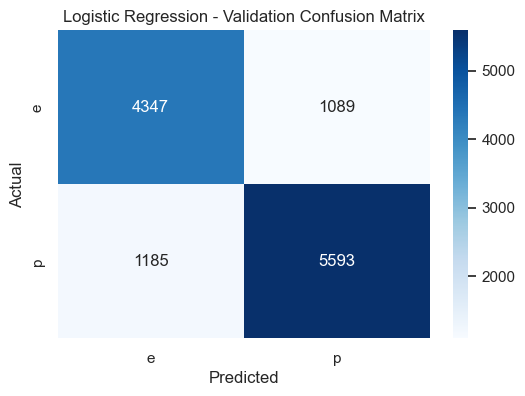

In [73]:
class_labels = ["e", "p"]
cm = confusion_matrix(y_val, y_val_pred, labels=class_labels)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title("Logistic Regression - Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#### Interpretation

The single validation split is the simplest validation method. I train several logistic regression models with different values of `C` and choose the one with the best F1 score for the poisonous class.

This method is fast and easy to explain, but it depends on one specific split. If the split is unlucky, the selected hyperparameter may not generalize well.

The confusion matrix shows that some poisonous mushrooms are still classified as edible. In this problem those false negatives are the most dangerous errors, so recall for the poisonous class matters more than plain accuracy.


In [76]:
recall_poisonous = recall_score(y_val, y_val_pred, pos_label="p")
print(f"Recall (poisonous): {recall_poisonous:.3f}")


Recall (poisonous): 0.825


The recall for the poisonous class tells us what proportion of actually poisonous mushrooms were detected as poisonous.

This is the key safety metric here, because a false negative means predicting a poisonous mushroom as edible.


## Stratified K-Fold Cross-Validation


In [ ]:
grid_parameters = {
    "model__C": [0.01, 0.1, 1, 10] # __ means we are tuning the C parameter of the model step in the pipeline
}

poisonous_f1_scorer = make_scorer(f1_score, pos_label="p")

five_fold_cv = StratifiedKFold( # Split data into folds for cross-validation
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV( # use to check diff. hyper parameters 
    model,
    grid_parameters,
    cv=five_fold_cv,
    scoring=poisonous_f1_scorer,
    n_jobs=1 # Use 1 to avoid issues with parallel processing in some environments
)

grid_search.fit(X_train_val, y_train_val)

print("Best C:", grid_search.best_params_)
print("Best average CV F1:", grid_search.best_score_)

Best C: {'model__C': 0.1}
Best average CV F1: 0.8300136886353584


In [82]:
cv_scores = cross_val_score(
    grid_search.best_estimator_, # Best model from grid search
    X_train_val,
    y_train_val,
    cv=five_fold_cv,
    scoring=poisonous_f1_scorer,
    n_jobs=1
)

print("Cross-validation F1 scores:", cv_scores)
print("Mean F1:", cv_scores.mean())
print("Std F1:", cv_scores.std())


Cross-validation F1 scores: [0.831305   0.82869855 0.82945154 0.83355276 0.82706059]
Mean F1: 0.8300136886353584
Std F1: 0.00223422602876236


In [84]:
best_model = grid_search.best_estimator_

#### Interpretation

Stratified K-Fold cross-validation is more stable than a single validation split because the model is trained and evaluated on several different folds.

I use stratification because this is a classification problem and I want each fold to preserve the edible/poisonous class ratio.

The downside is computation time: every hyperparameter value is trained several times. The benefit is a more reliable estimate than one validation split.


## Nested Cross-Validation


In [ ]:
outer_performance_cv = StratifiedKFold( # to evaluate performance
    n_splits=3,
    shuffle=True,
    random_state=24
)

inner_tuning_cv = StratifiedKFold( # to choose best C
    n_splits=3,
    shuffle=True,
    random_state=42
)

nested_cv_scores = cross_val_score(
    GridSearchCV(
        model,
        c_values_to_test,
        cv=inner_tuning_cv,
        scoring=poisonous_f1_scorer,
        n_jobs=1
    ),
    X_train_val,
    y_train_val,
    cv=outer_performance_cv,
    scoring=poisonous_f1_scorer,
    n_jobs=1
)

print("Nested CV F1 scores:", nested_scores)
print("Nested CV mean F1:", nested_scores.mean())
print("Nested CV std F1:", nested_scores.std())


Nested CV F1 scores: [0.82771451 0.82606494 0.83198029]
Nested CV mean F1: 0.8285865802443514
Nested CV std F1: 0.002492419772240288


#### Interpretation

Nested cross-validation separates hyperparameter tuning from performance estimation.

The inner loop selects the best hyperparameter, and the outer loop estimates performance on data not used for that inner tuning. This is less optimistic than using the same cross-validation both to tune and to report performance.

The trade-off is that nested CV is computationally expensive, so I use 3 outer folds and 3 inner folds to keep the notebook practical.

std - standard deviation

## Final Model


In [93]:
best_model.fit(X_train_val, y_train_val) # Fit the best model on the entire training+validation

y_test_pred = best_model.predict(X_test) # Predict on the test set using the best model from nested CV

## Confusion Matrix And Metrics


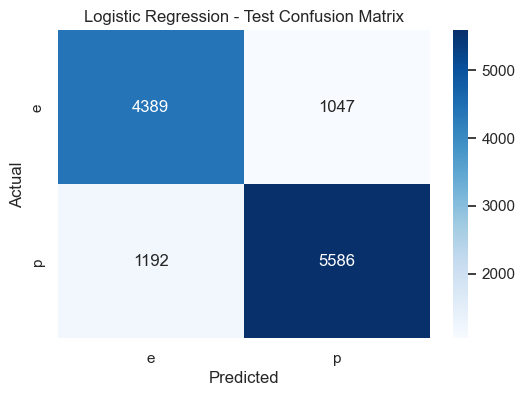

In [97]:
class_labels_test = ["e", "p"]
cm = confusion_matrix(y_test, y_test_pred, labels=class_labels_test)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels_test,
    yticklabels=class_labels_test
)
plt.title("Logistic Regression - Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [98]:
# test if probabilities are not reversed
best_model.classes_

array(['e', 'p'], dtype=object)

# ROC Curve
The ROC curve shows how well the model separates poisonous mushrooms from edible mushrooms at different decision thresholds.

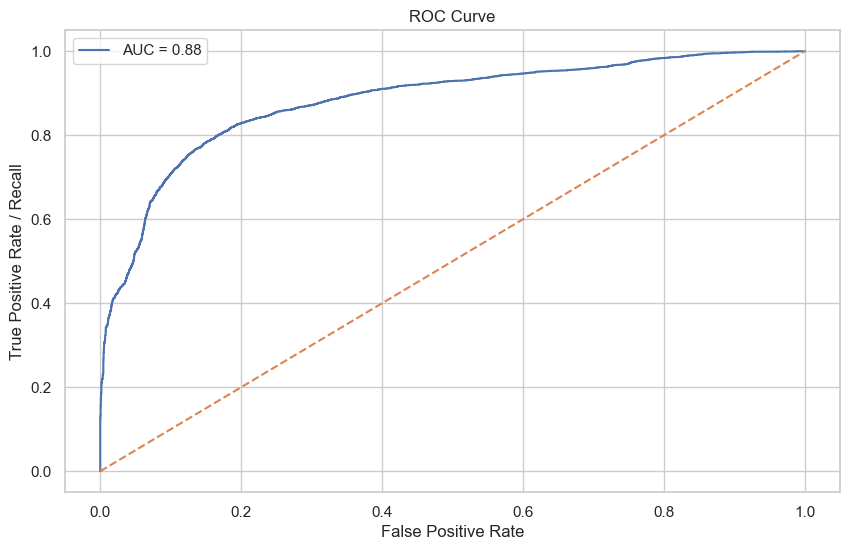

In [99]:
poisonous_index = list(best_model.classes_).index("p")
y_scores = best_model.predict_proba(X_test)[:, poisonous_index]

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_scores, pos_label="p")
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("ROC Curve")
plt.legend()
plt.show()


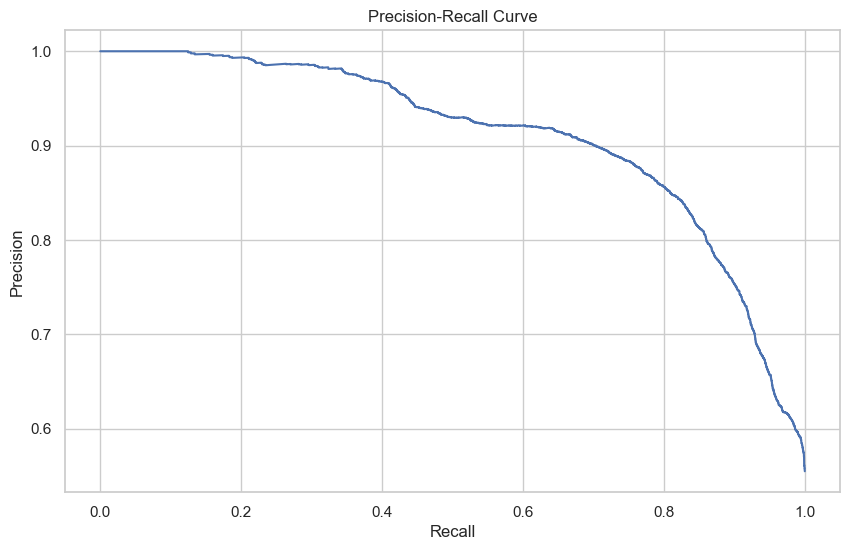

In [100]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_scores, pos_label="p")

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [101]:
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, pos_label="p"))
print("Recall:", recall_score(y_test, y_test_pred, pos_label="p"))
print("F1 Score:", f1_score(y_test, y_test_pred, pos_label="p"))
print("ROC AUC:", roc_auc_score(y_test, y_scores))


Accuracy: 0.8166857704273784
Precision: 0.8421528720036183
Recall: 0.8241369135438182
F1 Score: 0.8330474983222728
ROC AUC: 0.8815841669288446


### Interpretation

The final logistic regression model achieved about 82% accuracy and an F1-score of about 0.83 for the poisonous class on the held-out test set.

The confusion matrix shows that the model makes mostly correct predictions, but it still classifies some poisonous mushrooms as edible. These false negatives are the most important errors in this task, because in a real mushroom-foraging context they would be dangerous.

The ROC curve has an AUC of about 0.88, which means the model has good ability to separate edible and poisonous mushrooms. The precision-recall curve is also important here, because the key trade-off is between detecting poisonous mushrooms and avoiding too many false alarms.

For this problem, recall for the poisonous class is the most important metric. F1-score for the poisonous class is also useful, because it balances recall and precision. Accuracy alone is not enough, because it treats all mistakes as equally important.


### Limitations

The main limitation is that the model still produces false negatives, meaning some poisonous mushrooms are predicted as edible. Because of that, the model should not be treated as safe for real-world mushroom foraging.

The preprocessing was handled carefully to avoid data leakage: the data was split before fitting imputers, encoders, scalers or selecting columns to drop. Missing-value based column removal was decided using the training data only, then the same columns were removed from validation and test data.

The validation methods give a reasonable estimate of performance, but they do not remove the practical risk of dangerous misclassification. A safer system would need stronger recall for the poisonous class, possibly threshold tuning, more domain knowledge, or a different model comparison.
